In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [3]:
import pandas
data = pandas.read_csv('exoplanet_data.csv')
data = data[data['pl_rade'].notna() & data['pl_bmasse'].notna()]
data = data.drop_duplicates(subset = 'pl_name')
# data = data.drop_duplicates(subset = 'pl_rade')
data.to_csv('exoplanet_data.csv', index = False)

In [ ]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('exoplanet_data.csv')

data['radius'] = data['pl_rade']
data['mass'] = data['pl_bmasse']
data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)
data = data.drop_duplicates('radius')
data = data.reset_index(drop = True)
data

,radius,mass
0,0.320000,10.00000
1,0.470000,4.30000
2,0.500000,0.10000
3,0.510000,99.20000
4,0.540000,4.00000
...,...,...
1136,23.538859,375.03752
1137,24.660000,5403.00000
1138,30.264300,3496.13000
1139,33.600000,6356.00000


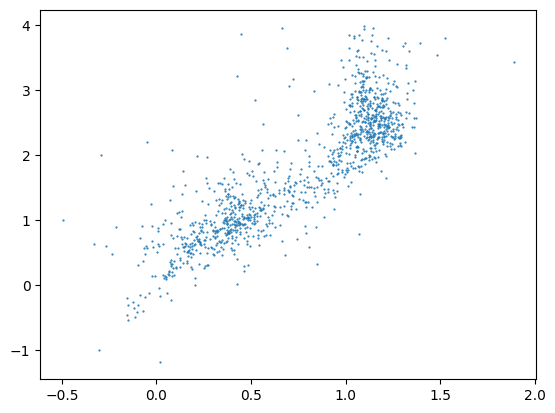

In [44]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

plot.scatter(x, y, s = 0.3)
# plot.loglog()
plot.show()

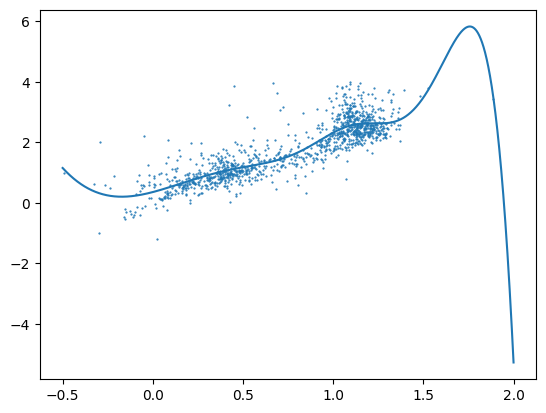

In [66]:
from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(x, y, k = 5, s = 240)

x_smooth = numpy.linspace(-0.5, 2, 10000)
y_smooth = spline(x_smooth)

plot.scatter(x, y, s = 0.3)
plot.plot(x_smooth, y_smooth)
plot.show()

from LogRMSpline import LogRMSpline
spline = LogRMSpline(spline, x, y)

spline.cap_min(-0.17239923992399236, 0.20479873358473308)
spline.cap_max(1.7573297329732975, 5.826543107129075)

In [67]:
import dill

with open('radius_mass_spline.pkl', 'wb') as file:
    dill.dump(spline, file)

Log Min: -1.0, -2.857324078696495
Log Max: 3.0, 6.240766529471309
Log Spread: 0.4586538995258751


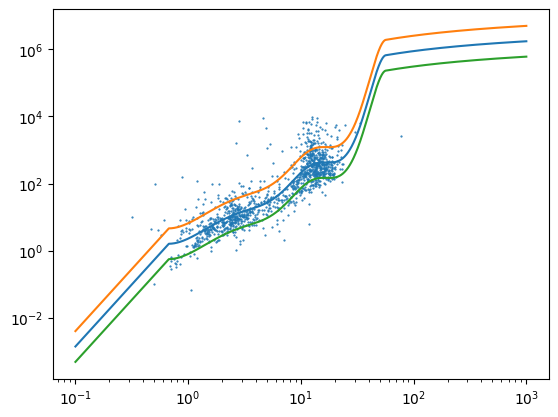

In [73]:
import dill
import matplotlib.pyplot as plot
import numpy

with open('radius_mass_spline.pkl', 'rb') as file:
    spline = dill.load(file)

x_smooth = numpy.linspace(-1, 3, 10000)
y_smooth = spline(x_smooth)

print(f'Log Min: {x_smooth[numpy.argmin(y_smooth)]}, {numpy.min(y_smooth)}')
print(f'Log Max: {x_smooth[numpy.argmax(y_smooth)]}, {numpy.max(y_smooth)}')
print(f'Log Spread: {spline.spread}')

# y_smooth[x_smooth < x_smooth[numpy.argmin(y_smooth)]] = y_smooth[numpy.argmin(y_smooth)]
# y_smooth[x_smooth > x_smooth[numpy.argmax(y_smooth)]] = y_smooth[numpy.argmax(y_smooth)]

# plot.scatter(x, y, s = 0.3)
# plot.plot(x_smooth, y_smooth)
# plot.plot(numpy.linspace(numpy.min(x_smooth), numpy.max(x_smooth), 10), numpy.linspace(numpy.log10(4130), numpy.log10(4130), 10))

plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth + spline.spread))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth - spline.spread))
plot.scatter(numpy.power(10, x), numpy.power(10, y), s = 0.3)

plot.loglog()
# plot.xlim(0, 25)
# plot.yscale('log')
plot.show()